<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/AVG_TEST_CNN_Example_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cpu



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [2]:

def train_classifier(model, train_loader, test_loader=None, epochs=5, learning_rate=1e-3, verbose=True):
    # Train a PyTorch classifier using cross-entropy loss.
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

        train_loss = total_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}, "
                    f"test loss = {test_loss:.4f}, test acc = {test_acc:.4f}"
                )
        else:
            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}"
                )

    return history


def evaluate_classifier(model, data_loader, criterion=None):
    # Evaluate classification loss and accuracy.
    model.eval()

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

    return total_loss / total, correct / total



## 4. Helper Function: Plot Training Curves


In [3]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [6]:


# ------------------------------------------------------------
# Basic ECG filtering
# ------------------------------------------------------------

def bandpass_filter_ecg(ecg, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Bandpass filter an ECG signal.

    Works for either:
        - 1D ECG array with shape (num_samples,)
        - 2D ECG array with shape (num_samples, num_leads)

    Parameters
    ----------
    ecg : ndarray
        ECG signal.
    fs : float
        Sampling frequency in Hz.
    lowcut : float
        Lower cutoff frequency in Hz.
    highcut : float
        Upper cutoff frequency in Hz.
    order : int
        Butterworth filter order.

    Returns
    -------
    ecg_filtered : ndarray
        Filtered ECG signal with the same shape as input.
    """
    ecg = np.asarray(ecg)

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")

    # axis=0 means we filter along time when ecg has shape (num_samples, num_leads)
    ecg_filtered = filtfilt(b, a, ecg, axis=0)

    return ecg_filtered


# ------------------------------------------------------------
# R-peak detection from one reference lead
# ------------------------------------------------------------

def detect_r_peaks(ecg_1d, fs, min_heart_rate=40, prominence=None, height=None):
    """
    Detect R-peaks from a single ECG lead.

    Parameters
    ----------
    ecg_1d : ndarray
        One ECG lead, shape (num_samples,).
    fs : float
        Sampling frequency in Hz.
    min_heart_rate : float
        Minimum expected heart rate in beats per minute.
    prominence : float or None
        Minimum peak prominence. If None, an automatic value is used.
    height : float or None
        Minimum peak height.

    Returns
    -------
    r_peaks : ndarray
        Indices of detected R-peaks.
    """
    ecg_1d = np.asarray(ecg_1d).ravel()

    min_distance = int(fs * 60 / min_heart_rate)

    if prominence is None:
        prominence = 0.5 * np.std(ecg_1d)

    r_peaks, _ = find_peaks(
        ecg_1d,
        distance=min_distance,
        prominence=prominence,
        height=height,
    )

    return r_peaks


# ------------------------------------------------------------
# Average heartbeat for all 12 leads
# ------------------------------------------------------------

def average_heartbeat_12lead(
    ecg_12lead,
    fs,
    r_peaks=None,
    reference_lead=1,
    pre_time=0.25,
    post_time=0.45,
):
    """
    Average multiple heartbeats for each lead of a 12-lead ECG.

    Parameters
    ----------
    ecg_12lead : ndarray
        ECG array with shape (num_samples, 12).
    fs : float
        Sampling frequency in Hz.
    r_peaks : ndarray or None
        R-peak indices. If None, R-peaks are detected from the reference lead.
    reference_lead : int
        Column index used for R-peak detection.
        For standard 12-lead order, lead II is index 1.
    pre_time : float
        Seconds before each R-peak to include.
    post_time : float
        Seconds after each R-peak to include.

    Returns
    -------
    avg_beats : ndarray
        Average heartbeat for each lead.
        Shape: (samples_per_beat, 12)

    beats : ndarray
        Individual segmented beats.
        Shape: (num_beats, samples_per_beat, 12)

    t_beat : ndarray
        Time vector for each averaged beat.
        Shape: (samples_per_beat,)

    r_peaks : ndarray
        R-peak locations used for averaging.
    """
    ecg_12lead = np.asarray(ecg_12lead)

    if ecg_12lead.ndim != 2:
        raise ValueError("ecg_12lead must be a 2D array with shape (num_samples, 12).")

    num_samples, num_leads = ecg_12lead.shape

    if num_leads != 12:
        raise ValueError(f"Expected 12 leads, but got {num_leads}.")

    if r_peaks is None:
        reference_signal = ecg_12lead[:, reference_lead]
        r_peaks = detect_r_peaks(reference_signal, fs)

    pre_samples = int(pre_time * fs)
    post_samples = int(post_time * fs)
    samples_per_beat = pre_samples + post_samples

    beats = []

    for r in r_peaks:
        start = r - pre_samples
        end = r + post_samples

        # Skip beats too close to the beginning or end
        if start >= 0 and end <= num_samples:
            beat = ecg_12lead[start:end, :]
            beats.append(beat)

    beats = np.array(beats)

    if beats.shape[0] == 0:
        raise ValueError(
            "No complete beats were found. "
            "Try changing pre_time/post_time or check R-peak detection."
        )

    avg_beats = np.mean(beats, axis=0)

    t_beat = np.arange(-pre_samples, post_samples) / fs

    return avg_beats, beats, t_beat, r_peaks


# ------------------------------------------------------------
# Plot average heartbeat for all 12 leads
# ------------------------------------------------------------

def plot_average_12lead(t_beat, avg_beats, lead_names=None):
    """
    Plot the averaged heartbeat from each of the 12 ECG leads.

    Parameters
    ----------
    t_beat : ndarray
        Time vector, shape (samples_per_beat,).
    avg_beats : ndarray
        Average beats, shape (samples_per_beat, 12).
    lead_names : list of str or None
        Names of the 12 ECG leads.
    """
    if lead_names is None:
        lead_names = [
            "I", "II", "III",
            "aVR", "aVL", "aVF",
            "V1", "V2", "V3",
            "V4", "V5", "V6",
        ]

    fig, axes = plt.subplots(4, 3, figsize=(12, 10), sharex=True)

    for lead_idx, ax in enumerate(axes.flat):
        ax.plot(t_beat, avg_beats[:, lead_idx], linewidth=2)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(f"Lead {lead_names[lead_idx]}")
        ax.grid(True)

    fig.supxlabel("Time relative to R-peak, seconds")
    fig.supylabel("ECG amplitude")
    fig.suptitle("Average Heartbeat for Each ECG Lead")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Optional: Plot individual beats and average for one lead
# ------------------------------------------------------------

def plot_individual_and_average_for_lead(
    t_beat,
    beats,
    avg_beats,
    lead_idx=1,
    lead_names=None,
):
    """
    Plot all segmented beats and the average beat for one selected lead.

    Parameters
    ----------
    t_beat : ndarray
        Time vector, shape (samples_per_beat,).
    beats : ndarray
        Individual beats, shape (num_beats, samples_per_beat, 12).
    avg_beats : ndarray
        Average beats, shape (samples_per_beat, 12).
    lead_idx : int
        Lead index to plot.
    lead_names : list of str or None
        Names of ECG leads.
    """
    if lead_names is None:
        lead_names = [
            "I", "II", "III",
            "aVR", "aVL", "aVF",
            "V1", "V2", "V3",
            "V4", "V5", "V6",
        ]

    plt.figure(figsize=(10, 5))

    for k in range(beats.shape[0]):
        plt.plot(t_beat, beats[k, :, lead_idx], color="gray", alpha=0.25)

    plt.plot(
        t_beat,
        avg_beats[:, lead_idx],
        color="black",
        linewidth=3,
        label="Average beat",
    )

    plt.axvline(0, linestyle="--", color="red", label="R-peak")
    plt.xlabel("Time relative to R-peak, seconds")
    plt.ylabel("ECG amplitude")
    plt.title(f"Individual and Average Beats: Lead {lead_names[lead_idx]}")
    plt.grid(True)
    plt.legend()
    plt.show()




In [16]:
from re import X
ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
#X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)

#for averaging
fs = 250

X_filt = np.array([
    bandpass_filter_ecg(x, fs)
    for x in X
])

X_ts = np.swapaxes(X, 1, 2)

X_avg_list = []
y_avg_list = []

valid_indices = []

for i in range(len(X_filt)):
    try:
        avg_beats, _, _, _ = average_heartbeat_12lead(
            X_filt[i],
            fs=fs,
            reference_lead=1
        )

        X_avg_list.append(avg_beats.T)
        y_avg_list.append(y_ts[i])
        valid_indices.append(i)

    except:
        continue

X_avg = np.array(X_avg_list)   # (N, 12, T)
y_avg = np.array(y_avg_list)


#fixed length
import scipy.signal

TARGET_LEN = 200  # good default for averaged beat ECGs

def resize(x):
    return scipy.signal.resample(x, TARGET_LEN, axis=1)

X_avg = np.array([resize(x) for x in X_avg])
X_avg = (X_avg - X_avg.mean(axis=2, keepdims=True)) / (
    X_avg.std(axis=2, keepdims=True) + 1e-8
)

(1000, 12, 2500)
(1000,)



## 11. Visualize Example Time Series


In [12]:

'''
plt.figure(figsize=(10, 5))
for class_label in range(3):
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()
'''


'\nplt.figure(figsize=(10, 5))\nfor class_label in range(3):\n    idx = np.where(y_ts == class_label)[0][0]\n    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")\n\nplt.xlabel("Time")\nplt.ylabel("Signal value")\nplt.title("Example Time Series from Each Class")\nplt.grid(True)\nplt.legend()\nplt.show()\n'


## 12. Create PyTorch DataLoaders for Time Series


In [17]:

X_ts_tensor = torch.tensor(X_avg, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_avg, dtype=torch.long)

print(X_ts_tensor.shape) #extra
print(y_ts_tensor.shape) #extra

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


torch.Size([999, 12, 200])
torch.Size([999])
torch.Size([32, 12, 200])
Time-series training samples: 799
Time-series test samples: 200



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [24]:
class TimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=200, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — compress heavily with large kernel
            nn.Conv1d(in_channels, 8, kernel_size=15, padding=7),
            nn.Tanh(),
            nn.Dropout(0.20),
            nn.MaxPool1d(kernel_size=2),   # 2500 → 500

            # Block 2 — compress again
            nn.Conv1d(8, 12, kernel_size=9, padding=4),
            nn.Tanh(),
            nn.Dropout(0.20),
            nn.MaxPool1d(kernel_size=2),   # 500 → 100

            # Block 3 — final compression
            nn.Conv1d(12, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # 100 → 20

            # Block 4 — final compression
            nn.Conv1d(16, 20, kernel_size=3, padding=2),
            nn.Tanh(),
            nn.MaxPool1d(kernel_size=2),   # 20 → 4


        )

        # 16 filters * 20 timesteps = 320 — much smaller than before (9984)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(260, 20),
            nn.ReLU(),
            nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2)
print(ts_model)

TimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(12, 8, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): Tanh()
    (2): Dropout(p=0.2, inplace=False)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(8, 12, kernel_size=(9,), stride=(1,), padding=(4,))
    (5): Tanh()
    (6): Dropout(p=0.2, inplace=False)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(12, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): ReLU()
    (10): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv1d(16, 20, kernel_size=(3,), stride=(1,), padding=(2,))
    (12): Tanh()
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=260, out_features=20, bias=True)
    (2): ReLU()
    (3): Linear(in_features=20, out_features=2,


## 14. Train the 1D CNN


Epoch 1/15: train loss = 0.6800, train acc = 0.6095, test loss = 0.6501, test acc = 0.7100
Epoch 2/15: train loss = 0.6316, train acc = 0.6658, test loss = 0.5974, test acc = 0.6850
Epoch 3/15: train loss = 0.5951, train acc = 0.6934, test loss = 0.5819, test acc = 0.7050
Epoch 4/15: train loss = 0.5771, train acc = 0.7146, test loss = 0.5877, test acc = 0.6850
Epoch 5/15: train loss = 0.5599, train acc = 0.7121, test loss = 0.5811, test acc = 0.7050
Epoch 6/15: train loss = 0.5472, train acc = 0.7397, test loss = 0.5837, test acc = 0.7200
Epoch 7/15: train loss = 0.5362, train acc = 0.7447, test loss = 0.5897, test acc = 0.7300
Epoch 8/15: train loss = 0.5195, train acc = 0.7572, test loss = 0.5850, test acc = 0.7250
Epoch 9/15: train loss = 0.5097, train acc = 0.7559, test loss = 0.5808, test acc = 0.7050
Epoch 10/15: train loss = 0.5081, train acc = 0.7534, test loss = 0.5772, test acc = 0.6900
Epoch 11/15: train loss = 0.5002, train acc = 0.7697, test loss = 0.5935, test acc = 0.72

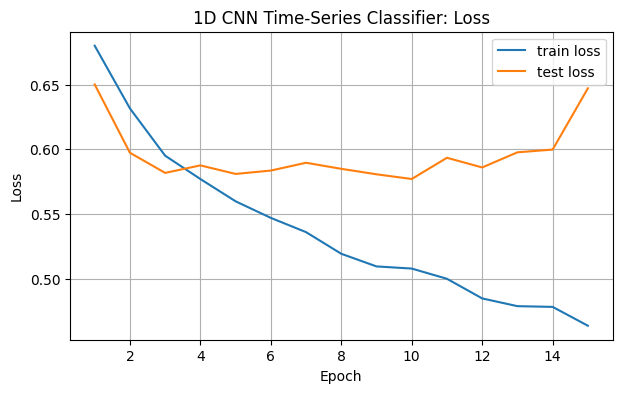

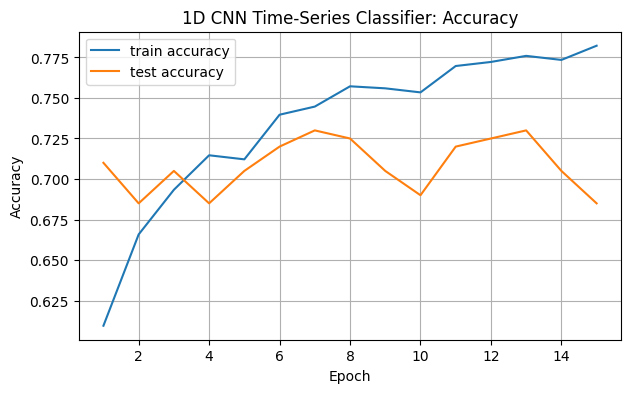

In [25]:

ts_history = train_classifier(
    ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=15, #no other num other than 15 works help us
    learning_rate=1e-3,
    verbose=True
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")



## 15. Inspect Time-Series Predictions


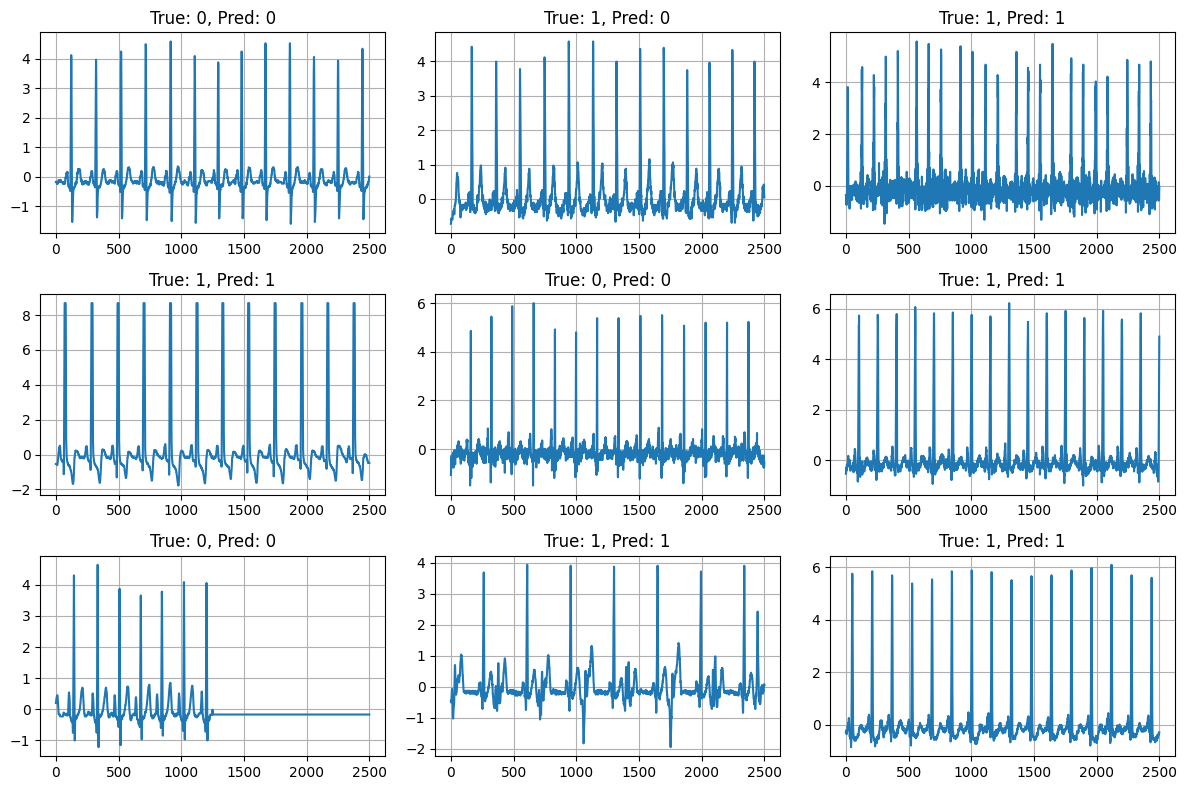

In [16]:

ts_model.eval()

X_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = ts_model(X_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_batch[i, 0].numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()



## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


In [17]:
'''
first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()
'''


'\nfirst_conv = ts_model.features[0]\nfilters = first_conv.weight.detach().cpu().numpy()\n\nplt.figure(figsize=(10, 6))\nfor i in range(filters.shape[0]):\n    plt.subplot(2, 4, i + 1)\n    plt.plot(filters[i, 0])\n    plt.title(f"Filter {i}")\n    plt.grid(True)\n\nplt.tight_layout()\nplt.show()\n'


# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.
